In [2]:
import pandas as pd
import numpy as np
import ast
from gensim.models import FastText
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib


In [3]:
df = pd.read_csv("Dataset/dataset_clean(SMOTE).csv")
df['tokens'] = df['tokens'].apply(ast.literal_eval) 
df.head()

,score,content,label,tokens
0,4,terlalu banyak iklan,1,"[terlalu, banyak, iklan]"
1,1,iklan lu terlalu lebih,0,"[iklan, lu, terlalu, lebih]"
2,5,ngedengerin musik idola sendiri pokok its the ...,1,"[ngedengerin, musik, idola, sendiri, pokok, it..."
3,2,jelek pas masuk aplikasi sering delay lagu pla...,0,"[jelek, pas, masuk, aplikasi, sering, delay, l..."
4,5,spotify udah bestie gua,1,"[spotify, udah, bestie, gua]"


In [4]:
#Split data untuk training dan testing
X = df['tokens']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Melatih model FastText
fasttext_model = FastText(
    sentences=X_train,
    vector_size=100,
    window=3,
    min_count=1,
    workers=4,
    sg=1  
)

In [6]:
def get_word_embeddings(tokens, model):
    vectors = []
    
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
        else:
            vectors.append(np.zeros(model.vector_size))
            
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
        
    return np.mean(vectors, axis=0)

In [7]:
# Mengubah data latih dan uji menjadi representasi vektor
X_train_vec = np.vstack([get_word_embeddings(tokens, fasttext_model) for tokens in X_train])
X_test_vec  = np.vstack([get_word_embeddings(tokens, fasttext_model) for tokens in X_test])

In [8]:
#SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_vec_smote, y_train_smote = smote.fit_resample(X_train_vec, y_train)

print("Distribusi label SEBELUM SMOTE :", dict(Counter(y_train)))
print("Distribusi label SETELAH SMOTE :", dict(Counter(y_train_smote)))
print(f"Total data latih setelah SMOTE: {len(y_train_smote)}\n")

Distribusi label SEBELUM SMOTE : {1: 2117, 0: 836}
Distribusi label SETELAH SMOTE : {1: 2117, 0: 2117}
Total data latih setelah SMOTE: 4234



In [9]:
# Inisialisasi Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_vec_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

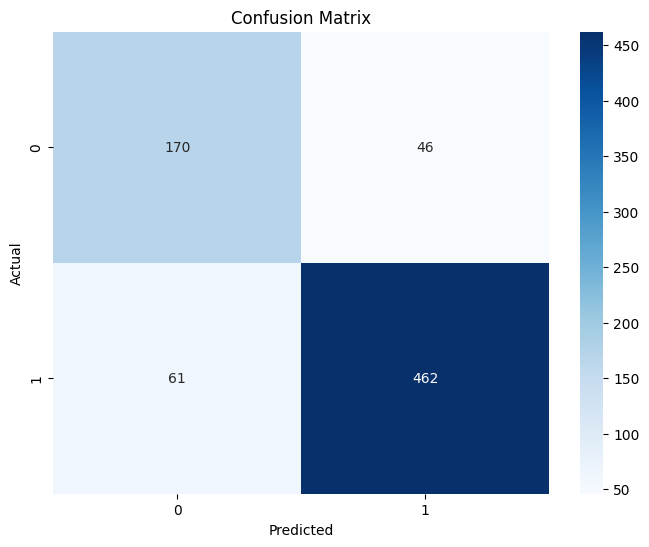

In [10]:
#confuseion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = rf_model.predict(X_test_vec)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:
# Evaluasi model
y_pred = rf_model.predict(X_test_vec)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       216
           1       0.91      0.88      0.90       523

    accuracy                           0.86       739
   macro avg       0.82      0.84      0.83       739
weighted avg       0.86      0.86      0.86       739



In [12]:
# K-Fold Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Gabungkan seluruh data yang sudah di-vectorize (sebelum SMOTE) untuk cross validation
X_all_vec = np.vstack([get_word_embeddings(tokens, fasttext_model) for tokens in X])
y_all = y.values

# Inisialisasi K-Fold (Stratified agar distribusi kelas seimbang di setiap fold)
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Model RF dengan parameter yang sama
rf_cv = RandomForestClassifier(n_estimators=300, random_state=42)

# Hitung metrik untuk setiap fold
acc_scores   = cross_val_score(rf_cv, X_all_vec, y_all, cv=skf, scoring='accuracy')
prec_scores  = cross_val_score(rf_cv, X_all_vec, y_all, cv=skf, scoring='precision_weighted')
rec_scores   = cross_val_score(rf_cv, X_all_vec, y_all, cv=skf, scoring='recall_weighted')
f1_scores    = cross_val_score(rf_cv, X_all_vec, y_all, cv=skf, scoring='f1_weighted')

print(f"{'='*55}")
print(f"  K-Fold Cross Validation (k={k}, Stratified)")
print(f"{'='*55}")
print(f"{'Fold':<8} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1-Score':>10}")
print(f"{'-'*55}")
for i, (acc, prec, rec, f1) in enumerate(zip(acc_scores, prec_scores, rec_scores, f1_scores), 1):
    print(f"{i:<8} {acc:>10.4f} {prec:>11.4f} {rec:>9.4f} {f1:>10.4f}")
print(f"{'-'*55}")
print(f"{'Mean':<8} {acc_scores.mean():>10.4f} {prec_scores.mean():>11.4f} {rec_scores.mean():>9.4f} {f1_scores.mean():>10.4f}")
print(f"{'Std':<8} {acc_scores.std():>10.4f} {prec_scores.std():>11.4f} {rec_scores.std():>9.4f} {f1_scores.std():>10.4f}")
print(f"{'='*55}")
print(f"\nRata-rata Accuracy  : {acc_scores.mean()*100:.2f}% ± {acc_scores.std()*100:.2f}%")
print(f"Rata-rata F1-Score  : {f1_scores.mean()*100:.2f}% ± {f1_scores.std()*100:.2f}%")


  K-Fold Cross Validation (k=5, Stratified)
Fold       Accuracy   Precision    Recall   F1-Score
-------------------------------------------------------
1            0.8376      0.8327    0.8376     0.8311
2            0.8444      0.8400    0.8444     0.8401
3            0.8347      0.8297    0.8347     0.8303
4            0.8184      0.8119    0.8184     0.8126
5            0.8645      0.8616    0.8645     0.8621
-------------------------------------------------------
Mean         0.8399      0.8352    0.8399     0.8352
Std          0.0150      0.0161    0.0150     0.0161

Rata-rata Accuracy  : 83.99% ± 1.50%
Rata-rata F1-Score  : 83.52% ± 1.61%


In [14]:
#save model rf dan fasttext
joblib.dump(rf_model, 'Model/Fasttext/SMOTE/rf_model.pkl')
fasttext_model.save('Model/Fasttext/SMOTE/fasttext_model.model')